In [57]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
#feature ingenering
from sklearn.decomposition import PCA

#models: importation & metrics
from sklearn.svm import SVC #with scal data
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier #with scal data
from sklearn.ensemble import GradientBoostingClassifier

#METRICS
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, matthews_corrcoef, f1_score

In [2]:
os.listdir()

['03_Lisowska_2014_suppData.csv',
 'datasets analysis and ML.ipynb',
 '03_Lisowska_2014_merg.csv',
 '03_Lisowska_2014.ipynb',
 '03_Lisowska_2014_clinical.csv',
 '.ipynb_checkpoints',
 'TTS_RECIST_GEX_MLclassification.ipynb',
 'GSE63885_series_matrix.csv',
 'Katarzyna Marta Lisowska 1.pdf',
 '03_Lisowska_2014_gex.csv']

In [3]:
df = pd.read_csv('03_Lisowska_2014_merg.csv')
df.head()

/home/dina/anaconda3/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3441: DtypeWarning: Columns (2,10,11,12) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


,patient_ID,hist_type,adj_chemotherapy,brca1_mutation,"tp53_mutation(mut=0, nonmut=1)",Tumor_grade,figo_stage,residual_tumor_size_R0,residual_tumor_size_R1,residual_tumor_size_R2,...,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at,!series_matrix_table_end
0,GSM1559299,serous ovarian,platinum/cyclophosphamide,no mutation,0.0,g4 - undifferentiated): G4,figo_stage: IIIC,residual tumor size (r0 < 1 cm,1 < r1 < 5 cm,r2 > 5cm): R2,...,11.574111,13.322110,13.215613,14.237047,13.441627,13.674595,13.327351,13.367631,13.055561,NaN
1,GSM1559300,serous ovarian,platinum/cyclophosphamide,no mutation,1.0,g4 - undifferentiated): G4,figo_stage: IIIC,residual tumor size (r0 < 1 cm,1 < r1 < 5 cm,r2 > 5cm): R2,...,11.271339,12.805103,12.779178,14.133160,13.584627,13.652071,13.198092,13.455391,12.957519,NaN
2,GSM1559301,serous ovarian,taxane/platinum,no mutation,0.0,g4 - undifferentiated): G3,figo_stage: IV,residual tumor size (r0 < 1 cm,1 < r1 < 5 cm,r2 > 5cm): R1,...,10.976503,13.173446,13.045407,14.207511,13.487807,13.702915,13.144366,13.256137,12.912805,NaN
3,GSM1559302,serous ovarian,platinum/cyclophosphamide,no mutation,0.0,g4 - undifferentiated): G3,figo_stage: IIIC,residual tumor size (r0 < 1 cm,1 < r1 < 5 cm,r2 > 5cm): R1,...,11.640626,13.503529,13.563336,14.105158,13.372322,13.561347,13.285036,13.040568,12.909776,NaN
4,GSM1559303,serous ovarian,taxane/platinum,no mutation,0.0,g4 - undifferentiated): G2,figo_stage: IIIC,residual tumor size (r0 < 1 cm,1 < r1 < 5 cm,r2 > 5cm): R1,...,11.583015,13.245380,13.151198,14.179832,13.646604,13.687820,13.126756,13.415375,13.050473,NaN


In [4]:
df.shape

(101, 54689)

In [5]:
df.columns[:14]

Index(['patient_ID', 'hist_type', 'adj_chemotherapy', 'brca1_mutation',
       'tp53_mutation(mut=0, nonmut=1)', 'Tumor_grade', 'figo_stage',
       'residual_tumor_size_R0', 'residual_tumor_size_R1',
       'residual_tumor_size_R2', 'RECIST', 'DFS(day)', 'OS(day)', '1007_s_at'],
      dtype='object')

In [6]:
df.set_index('patient_ID', inplace=True)

In [7]:
#mask 
df = df[df.columns[9:]]

In [8]:
df.drop(['DFS(day)', 'OS(day)'], axis=1, inplace=True)

In [9]:
df.head()

,RECIST,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,...,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at,!series_matrix_table_end
patient_ID,,,,,,,,,,,,,,,,,,,,,
GSM1559299,P,11.626937,9.002539,7.270261,11.885396,4.255623,8.979765,6.934770,7.069164,8.073915,...,11.574111,13.322110,13.215613,14.237047,13.441627,13.674595,13.327351,13.367631,13.055561,NaN
GSM1559300,P,11.821710,8.465106,7.848213,11.778074,4.602319,8.705305,6.747927,6.864507,10.404432,...,11.271339,12.805103,12.779178,14.133160,13.584627,13.652071,13.198092,13.455391,12.957519,NaN
GSM1559301,P,12.102535,9.552282,7.889065,11.821385,5.253344,8.724364,6.744109,6.700919,8.140739,...,10.976503,13.173446,13.045407,14.207511,13.487807,13.702915,13.144366,13.256137,12.912805,NaN
GSM1559302,P,11.114703,10.080449,7.616009,11.420668,4.444839,8.593362,6.641933,6.964967,5.829263,...,11.640626,13.503529,13.563336,14.105158,13.372322,13.561347,13.285036,13.040568,12.909776,NaN
GSM1559303,P,11.943312,10.225346,7.353331,12.232684,4.092267,9.003311,6.499936,6.894400,7.532061,...,11.583015,13.245380,13.151198,14.179832,13.646604,13.687820,13.126756,13.415375,13.050473,NaN


In [10]:
#shape
print(df.shape)

(101, 54677)


In [11]:
#target
df.RECIST

patient_ID
GSM1559299      P
GSM1559300      P
GSM1559301      P
GSM1559302      P
GSM1559303      P
             ... 
GSM1559395    NaN
GSM1559396    NaN
GSM1559397    NaN
GSM1559398    NaN
GSM1559399    NaN
Name: RECIST, Length: 101, dtype: object

In [12]:
#types of variables
df.dtypes.unique().tolist()

[dtype('O'), dtype('float64')]

In [13]:
#check missing rate
(df.isna().sum()/df.shape[0]).sort_values(ascending=True)

218052_s_at                 0.000000
227188_at                   0.000000
227189_at                   0.000000
227190_at                   0.000000
227191_at                   0.000000
                              ...   
208814_at                   0.000000
208816_x_at                 0.000000
AFFX-TrpnX-5_at             0.000000
RECIST                      0.257426
!series_matrix_table_end    1.000000
Length: 54677, dtype: float64

In [14]:
#remove last columns
df = df.drop('!series_matrix_table_end', axis=1)

In [17]:
#drop nan from RECIST ===> into 75 samples
df.dropna(inplace=True)
print(df.shape)

(75, 54676)


<AxesSubplot:ylabel='RECIST'>

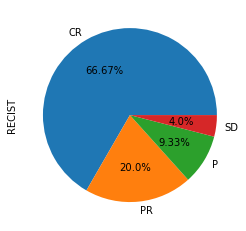

In [19]:
#distribution of my target ===> unbalanced
df['RECIST'].value_counts().plot.pie(autopct = lambda x: str(round(x, 2)) + '%')

/home/dina/anaconda3/lib/python3.8/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:ylabel='Density'>

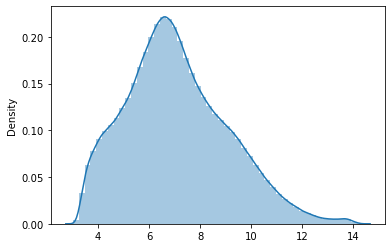

In [20]:
#distribution of expression values
sns.distplot(df.iloc[:, 1:])

distribution seems to be normal 

maybe some outliers between 11 and 14

In [21]:
#preprocessing

print(df['RECIST'].unique())
dico = {'CR':0, 'PR':1, 'P':2, 'SD':3}
df['RECIST'] = df['RECIST'].map(dico)
print(df['RECIST'].unique())

['P' 'PR' 'SD' 'CR']
[2 1 3 0]


In [22]:
df.head()

,RECIST,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
patient_ID,,,,,,,,,,,,,,,,,,,,,
GSM1559299,2,11.626937,9.002539,7.270261,11.885396,4.255623,8.979765,6.934770,7.069164,8.073915,...,11.863697,11.574111,13.322110,13.215613,14.237047,13.441627,13.674595,13.327351,13.367631,13.055561
GSM1559300,2,11.821710,8.465106,7.848213,11.778074,4.602319,8.705305,6.747927,6.864507,10.404432,...,11.591094,11.271339,12.805103,12.779178,14.133160,13.584627,13.652071,13.198092,13.455391,12.957519
GSM1559301,2,12.102535,9.552282,7.889065,11.821385,5.253344,8.724364,6.744109,6.700919,8.140739,...,11.235868,10.976503,13.173446,13.045407,14.207511,13.487807,13.702915,13.144366,13.256137,12.912805
GSM1559302,2,11.114703,10.080449,7.616009,11.420668,4.444839,8.593362,6.641933,6.964967,5.829263,...,11.974841,11.640626,13.503529,13.563336,14.105158,13.372322,13.561347,13.285036,13.040568,12.909776
GSM1559303,2,11.943312,10.225346,7.353331,12.232684,4.092267,9.003311,6.499936,6.894400,7.532061,...,11.801845,11.583015,13.245380,13.151198,14.179832,13.646604,13.687820,13.126756,13.415375,13.050473


In [23]:
#check if there is redandance in variables ===> no redancance
print(df.columns.unique().size)
print(df.shape[1])

54676
54676


In [24]:
#check if there is empty cells ==> no empty
df.isnull().values.any()

False

/home/dina/anaconda3/lib/python3.8/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:ylabel='Density'>

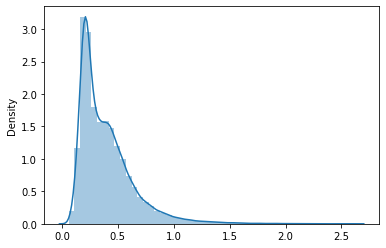

In [25]:
#distribution of standard deviation 
std_rate = df.iloc[:, 1:].std(axis=0)
sns.distplot(std_rate)

In [26]:
print('std min : ',df.iloc[:, 1:].std(axis=0).min())
print('std max: ',df.iloc[:, 1:].std(axis=0).max())

std min :  0.05959173030561891
std max:  2.6176640041441734


In [48]:
#13594 features with std superior than 0.5
std_rate[std_rate>0.5]

1053_at                    0.501955
1294_at                    0.579006
1405_i_at                  1.075940
1438_at                    0.792919
1552256_a_at               0.533680
                             ...   
AFFX-HUMRGE/M10098_M_at    0.817270
AFFX-M27830_5_at           1.149971
AFFX-M27830_M_at           0.521661
AFFX-r2-Bs-dap-5_at        0.662643
AFFX-r2-Ec-bioB-M_at       0.515450
Length: 13594, dtype: float64

In [47]:
#select features with more than .5 std
df_std = df.loc[:, df.std() > .5]
df_std.head()

,RECIST,1053_at,1294_at,1405_i_at,1438_at,1552256_a_at,1552261_at,1552263_at,1552264_a_at,1552269_at,...,AFFX-HUMISGF3A/M97935_5_at,AFFX-HUMISGF3A/M97935_MA_at,AFFX-HUMISGF3A/M97935_MB_at,AFFX-HUMRGE/M10098_3_at,AFFX-HUMRGE/M10098_5_at,AFFX-HUMRGE/M10098_M_at,AFFX-M27830_5_at,AFFX-M27830_M_at,AFFX-r2-Bs-dap-5_at,AFFX-r2-Ec-bioB-M_at
patient_ID,,,,,,,,,,,,,,,,,,,,,
GSM1559299,2,9.002539,8.979765,8.073915,7.234648,9.207055,7.945879,9.427180,8.728441,5.254062,...,6.685692,10.051168,10.520599,7.632046,6.246842,6.102492,8.192189,9.788157,10.312739,8.282913
GSM1559300,2,8.465106,8.705305,10.404432,8.781409,8.805175,6.756222,8.920478,8.675779,5.646345,...,6.787474,9.139729,9.401381,6.117860,4.890271,4.557777,5.541556,8.914455,11.199077,7.798050
GSM1559301,2,9.552282,8.724364,8.140739,9.213489,8.690168,7.152212,7.724031,8.570934,5.920141,...,7.702419,10.005655,10.261895,7.055277,5.834103,5.571444,8.536550,9.579703,9.893025,7.373838
GSM1559302,2,10.080449,8.593362,5.829263,7.434993,10.194926,7.333665,7.936305,8.437918,5.615623,...,7.206995,9.272666,9.808337,8.205886,6.979415,6.836400,9.500706,9.786949,10.425716,9.018910
GSM1559303,2,10.225346,9.003311,7.532061,8.812759,8.867244,8.510049,7.964830,9.228569,6.731005,...,8.391611,10.242956,10.072659,7.379086,6.618934,6.341308,8.415853,9.787541,10.886727,8.250433


In [49]:
#split all features
X = df.drop('RECIST', axis=1)
y = df['RECIST']

print(X.shape, y.shape)

(75, 54675) (75,)


In [61]:
#split all features
X_std = df_std.drop('RECIST', axis=1)
y_std = df_std['RECIST']

print(X_std.shape, y_std.shape)

(75, 13594) (75,)


In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, test_size=0.25)
print(X_train.shape, X_test.shape)

X_train_std, X_test_std, y_train_std, y_test_std = train_test_split(X_std, y_std, random_state=0, test_size=0.25)
print(X_train_std.shape, X_test_std.shape)



(56, 54675) (19, 54675)
(56, 13594) (19, 13594)


/home/dina/anaconda3/lib/python3.8/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).
  warnings.warn(msg, FutureWarning)
/home/dina/anaconda3/lib/python3.8/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).
  warnings.warn(msg, FutureWarning)


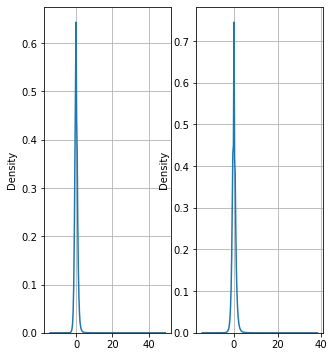

In [51]:
#robust scaler ==> robust to outliers
X_train_rb = RobustScaler().fit_transform(X_train)
X_test_rb = RobustScaler().fit_transform(X_test)

plt.figure(figsize=(5,6))
plt.subplot(121)
sns.distplot(X_train_rb, hist=False)
plt.grid(True)
plt.subplot(122)
sns.distplot(X_test_rb, hist=False)
plt.grid(True)

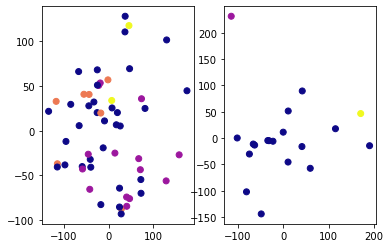

In [104]:
#PRINCIPAL COMPONENT ANALYSIS (PCA) : reduce feature number, 
#ATTENTION : data must be scalled before
pca = PCA(n_components=19)
x_train_pca = pca.fit_transform(X_train_rb)
x_test_pca = pca.fit_transform(X_test_rb)
plt.subplot(121)
plt.scatter(x_train_pca[:,0], x_train_pca[:,1], c=y_train,cmap='plasma')
plt.subplot(122)
plt.scatter(x_test_pca[:,0], x_test_pca[:,1], c=y_test,cmap='plasma')

In [105]:
pca.components_ #values of best components

array([[ 1.96427317e-03,  5.93935000e-03, -2.09541669e-03, ...,
        -4.65026877e-03,  4.70890638e-04, -2.38283471e-03],
       [ 4.94694713e-03, -1.04570802e-03, -1.27036935e-03, ...,
        -4.51368201e-03, -1.51012766e-02, -6.05877257e-03],
       [-4.35330266e-04,  3.58639842e-04, -6.41560817e-03, ...,
         1.65306941e-03,  5.54585038e-03,  1.75060204e-03],
       ...,
       [ 2.31751884e-03,  1.92162464e-03, -1.03426268e-03, ...,
         9.67908199e-04, -2.82894609e-03, -2.25943835e-03],
       [ 5.27276424e-03,  8.86570217e-03,  2.66167503e-03, ...,
         1.88040445e-04,  7.85251491e-04,  5.69205825e-04],
       [-1.80062776e-01,  3.33260526e-01,  2.87220259e-01, ...,
        -1.79799756e-04,  1.56491733e-05,  1.56647144e-05]])

In [106]:
#standard deviation 
print(x_train_pca.std(axis=0))

#standard deviation test set
print(x_test_pca.std(axis=0))

[67.75377106 56.07822916 44.1498587  40.96893573 39.91182822 38.34480215
 34.19541344 32.67753327 31.38662678 30.90586368 30.23240848 28.69839683
 28.31793095 26.9689441  26.65633871 26.14489012 25.570395   25.11058283
 24.79223195]
[8.40431447e+01 7.42784715e+01 5.73247025e+01 5.56767322e+01
 5.34549752e+01 4.89954840e+01 4.80861340e+01 4.69957688e+01
 4.57889148e+01 4.35566603e+01 4.24609040e+01 4.13421820e+01
 4.03871428e+01 3.97154125e+01 3.76471495e+01 3.68590115e+01
 3.58937541e+01 3.36458540e+01 1.79615201e-27]


### Training with all features

In [58]:
#without hyperparametrs / df
svc = SVC()
knn = KNeighborsClassifier(n_neighbors=5)
nb = GaussianNB()
dt = DecisionTreeClassifier(random_state=0)
mlp = MLPClassifier(random_state=0)
xgb = GradientBoostingClassifier(random_state=0)
dico_pred = {}
dico_acc = {}
dico_mcc = {}

models = [svc,knn,nb,dt,mlp, xgb]
for clf in models:
    clf.fit(X_train, y_train)
    dico_pred[clf] = clf.predict(X_test)
    dico_acc[clf] = clf.score(X_test, y_test)
    dico_mcc[clf] = matthews_corrcoef(y_test, clf.predict(X_test))

/home/dina/anaconda3/lib/python3.8/site-packages/sklearn/metrics/_classification.py:873: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)
/home/dina/anaconda3/lib/python3.8/site-packages/sklearn/metrics/_classification.py:873: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)


In [59]:
dico_pred.keys()

dict_keys([SVC(), KNeighborsClassifier(), GaussianNB(), DecisionTreeClassifier(random_state=0), MLPClassifier(random_state=0), GradientBoostingClassifier(random_state=0)])

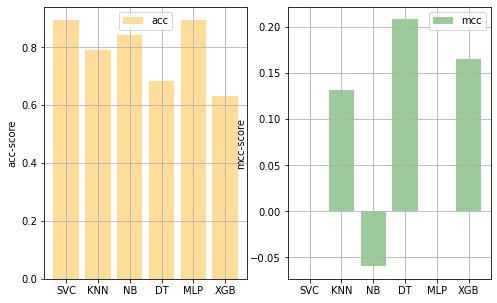

In [60]:
plt.figure(figsize=(8,5))
plt.subplot(121)
plt.bar(['SVC','KNN','NB','DT','MLP','XGB'],dico_acc.values(),color='orange',alpha=0.4 ,label='acc')
plt.ylabel('acc-score')
plt.grid(True)
plt.legend()
plt.subplot(122)
plt.bar(['SVC','KNN','NB','DT','MLP','XGB'],dico_mcc.values(),color='green',alpha=0.4 ,label='mcc')
plt.ylabel('mcc-score')
plt.grid(True)
plt.legend()
plt.show()

In [98]:
print('best_mcc : {} is from dt'.format(dico_mcc[dt].round(3)))
print('acc : {}'.format(dico_acc[dt].round(3)))
print(f1_score(y_test, dico_pred[xgb], average='weighted'))

best_mcc : 0.208 is from dt
acc : 0.684
0.6963097398669087


In [99]:

for clf in models:
    print('{} ==> {} '.format(clf, f1_score(y_test, dico_pred[clf], average='weighted')))
    

SVC() ==> 0.8450292397660818 
KNeighborsClassifier() ==> 0.8133971291866028 
GaussianNB() ==> 0.8180451127819549 
DecisionTreeClassifier(random_state=0) ==> 0.775438596491228 
MLPClassifier(random_state=0) ==> 0.8450292397660818 
GradientBoostingClassifier(random_state=0) ==> 0.6963097398669087 


In [63]:
#without hyperparametrs / df_std

dico_pred_std = {}
dico_acc_std = {}
dico_mcc_std = {}

for clf in models:
    clf.fit(X_train_std, y_train_std)
    dico_pred_std[clf] = clf.predict(X_test_std)
    dico_acc_std[clf] = clf.score(X_test_std, y_test_std)
    dico_mcc_std[clf] = matthews_corrcoef(y_test_std, clf.predict(X_test_std))

/home/dina/anaconda3/lib/python3.8/site-packages/sklearn/metrics/_classification.py:873: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)
/home/dina/anaconda3/lib/python3.8/site-packages/sklearn/metrics/_classification.py:873: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)


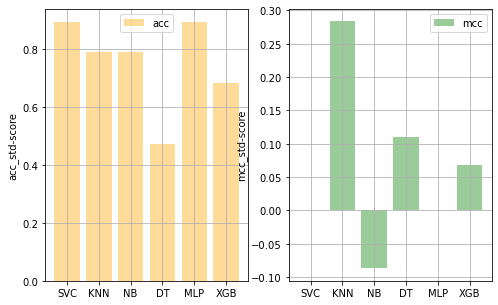

In [64]:
plt.figure(figsize=(8,5))
plt.subplot(121)
plt.bar(['SVC','KNN','NB','DT','MLP','XGB'],dico_acc_std.values(),color='orange',alpha=0.4 ,label='acc')
plt.ylabel('acc_std-score')
plt.grid(True)
plt.legend()
plt.subplot(122)
plt.bar(['SVC','KNN','NB','DT','MLP','XGB'],dico_mcc_std.values(),color='green',alpha=0.4 ,label='mcc')
plt.ylabel('mcc_std-score')
plt.grid(True)
plt.legend()
plt.show()

In [70]:
print('best_mcc : {} is from knn'.format(dico_mcc_std[knn].round(3)))
print('acc : {}'.format(dico_acc_std[knn].round(3)))

best_mcc : 0.284 is from knn
acc : 0.789


In [107]:
#with scaled data / df

dico_pred_rb = {}
dico_acc_rb = {}
dico_mcc_rb = {}

for clf in models:
    clf.fit(X_train_rb, y_train)
    dico_pred_rb[clf] = clf.predict(X_test_rb)
    dico_acc_rb[clf] = clf.score(X_test_rb, y_test)
    dico_mcc_rb[clf] = matthews_corrcoef(y_test, clf.predict(X_test_rb))

/home/dina/anaconda3/lib/python3.8/site-packages/sklearn/metrics/_classification.py:873: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)


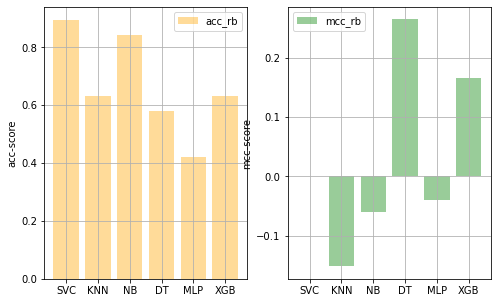

In [73]:
plt.figure(figsize=(8,5))
plt.subplot(121)
plt.bar(['SVC','KNN','NB','DT','MLP','XGB'],dico_acc_rb.values(),color='orange',alpha=0.4 ,label='acc_rb')
plt.ylabel('acc-score')
plt.grid(True)
plt.legend()
plt.subplot(122)
plt.bar(['SVC','KNN','NB','DT','MLP','XGB'],dico_mcc_rb.values(),color='green',alpha=0.4 ,label='mcc_rb')
plt.ylabel('mcc-score')
plt.grid(True)
plt.legend()
plt.show()

In [77]:
print('best_mcc : {} is from dt'.format(dico_mcc_rb[dt].round(3)))
print('acc : {}'.format(dico_acc_rb[dt].round(3)))

print('decision tree have more big mcc with robust data than mcc with just original data')

best_mcc : 0.265 is from dt
acc : 0.579
decision tree have more big mcc with robust data than mcc with just original data


/home/dina/anaconda3/lib/python3.8/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).
  warnings.warn(msg, FutureWarning)
/home/dina/anaconda3/lib/python3.8/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).
  warnings.warn(msg, FutureWarning)
/home/dina/anaconda3/lib/python3.8/site-packages/sklearn/metrics/_classification.py:873: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)


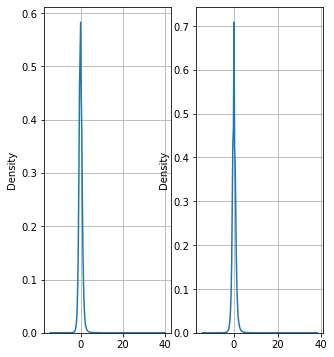

In [81]:
#scal df_std with robustscaler
X_train_std_rb = RobustScaler().fit_transform(X_train_std)
X_test_std_rb = RobustScaler().fit_transform(X_test_std)

plt.figure(figsize=(5,6))
plt.subplot(121)
sns.distplot(X_train_std_rb, hist=False)
plt.grid(True)
plt.subplot(122)
sns.distplot(X_test_std_rb, hist=False)
plt.grid(True)

#with scaled data / df_std

dico_pred_std_rb = {}
dico_acc_std_rb = {}
dico_mcc_std_rb = {}

for clf in models:
    clf.fit(X_train_std_rb, y_train_std)
    dico_pred_std_rb[clf] = clf.predict(X_test_std_rb)
    dico_acc_std_rb[clf] = clf.score(X_test_std_rb, y_test_std)
    dico_mcc_std_rb[clf] = matthews_corrcoef(y_test_std, clf.predict(X_test_std_rb))

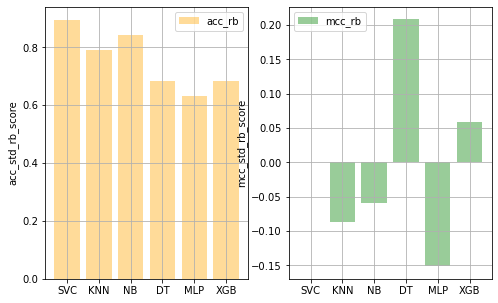

In [82]:
plt.figure(figsize=(8,5))
plt.subplot(121)
plt.bar(['SVC','KNN','NB','DT','MLP','XGB'],dico_acc_std_rb.values(),color='orange',alpha=0.4 ,label='acc_rb')
plt.ylabel('acc_std_rb_score')
plt.grid(True)
plt.legend()
plt.subplot(122)
plt.bar(['SVC','KNN','NB','DT','MLP','XGB'],dico_mcc_std_rb.values(),color='green',alpha=0.4 ,label='mcc_rb')
plt.ylabel('mcc_std_rb_score')
plt.grid(True)
plt.legend()
plt.show()

In [85]:
print(dico_mcc_std_rb[dt])
print(dico_acc_std_rb[dt])
print()

0.20840310818416558
0.6842105263157895


In [108]:
# models with PCA
dico_pred_pca = {}
dico_acc_pca = {}
dico_mcc_pca = {}

for clf in models:
    clf.fit(x_train_pca, y_train)
    dico_pred_pca[clf] = clf.predict(x_test_pca)
    dico_acc_pca[clf] = clf.score(x_test_pca, y_test)
    dico_mcc_pca[clf] = matthews_corrcoef(y_test, clf.predict(x_test_pca))

/home/dina/anaconda3/lib/python3.8/site-packages/sklearn/metrics/_classification.py:873: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)


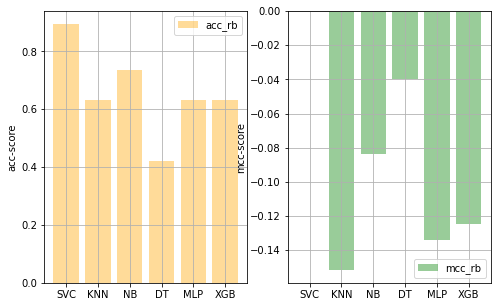

In [109]:
plt.figure(figsize=(8,5))
plt.subplot(121)
plt.bar(['SVC','KNN','NB','DT','MLP','XGB'],dico_acc_pca.values(),color='orange',alpha=0.4 ,label='acc_rb')
plt.ylabel('acc-score')
plt.grid(True)
plt.legend()
plt.subplot(122)
plt.bar(['SVC','KNN','NB','DT','MLP','XGB'],dico_mcc_pca.values(),color='green',alpha=0.4 ,label='mcc_rb')
plt.ylabel('mcc-score')
plt.grid(True)
plt.legend()
plt.show()